In [49]:
from dataclasses import dataclass
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import pandas as pd

# Define the math

The goal of this notebook is to use the revenue and value function provided by Legros et al. in the paper *Should We Wait Before Outsourcing? Analysis of a Revenue-Generating Blended Contact Center*

They modelled revenue $E(G)$ as a function of two type of calls. Class-1 refers to calls about inbound problems and Class-2 refers to outbound calls. Specifically, if a customer comes to the call center with a problem, then it is an inbound Class-1 call. However, if the call center agent had to call the customers, then it would be Class-2. The authors also modelled outsourcing as a form of cost saving. The call center has a contract with another company where the can allocate $P_{\bar{S}} \in (0, 1)$ of their inbound calls to that other company. 

To model revenue, they treat each class separately. The revenue for inbound Class-1 calls is a product of revenue per call $r_1$, arrival rate $\lambda$, number of calls taken in-house $(1 - P_{\bar{S}})$, and waiting time $E(W_s)$. The revenue for outbound Class-2 calls is treated more simply with revenue per call $r_2$ and throughput $T$. We finally just have the expense from the other company of $C_\text{outs}$. Overall, the revenue is
$$E(G) = r_2E(T) + r_1 \lambda (1 - P_{\bar{S}})(1 - \omega E(W_S)) - C_{\text{outs}}$$


For the value funciton, I would be focusing on the a posteriori policies where inbound calls are outsourced after some period of time. 
For clarity, our state space is $[-s, \infty)$ where if $x \in [-s, 0]$, it means how many free live agents are there. For example, if $s=4$ and $x=-3$, then it means there are three free servers and one busy server. Hence, $s+x$ agents are busy and thus helping out in the service rate $\mu$. For $x > 0$, we actually discretized the FIL waiting time into smaller chunks. Because we now have many small chunks, we would aggregate over this by having an operator $F$ on the set of functions $f:\mathbb{Z} \to \mathbb{R}$ defined by $F(f(x)) = \sum_{h=0}^x q_{x, x-h} f(x-h)$ for $x > 0$ and $F(f(x)) = f(x)$ for $x \leq 0$. "This operator is used to simplify the notations. It represents the possible changes in the state of the FIL when eitther an outsourcing or a service completion occurs"
This was done to approximate the continuous-time markov chain. However, this just makes the math a bit harder. 

For the value function $V_k(x)$, we consider $U_k(x)$ and $W_k(x)$. The former tells us about decisions on outsourcing or not. Later on, there will be the $\max$ operator to show that $U_k(x)$ will determine if it is more beneficial to outsource or just let the new customer enter the queue. For the latter, $W_k(x)$ representes the alue after making a service decision for Class-2 calls. There will also be the $\max$ operator to show a decision if it is better to take on an outbound call or just wait.


Finally, $k$ here just acts as a way to index the bellman backup. We are just going to reiteratively loop until $V$ converges. 
Anyways, there are two cases to consider:
* Case 1 - When $x \in [-s, 0]$:
$$V_{k+1} = \lambda U_k(x) + (s+x) \mu W_{k+1}(x-1) + \big(1 - \lambda - (s + x) \mu \big) W_k(x), $$
where
\begin{align*}
U_k(x) &= V_k(x+1) + r_1, \\  
W_k(x) &= \max \big\{V_k(x), V_k(x+1) + r_2 \big\}.
\end{align*}
* Case 2 - When $x \in (0, \infty)$:
$$V_{k+1}(x) = \gamma U_k(x) + s \mu \big( F(W_k(x)) + r_1 (1 - \omega \frac{x}{\gamma}) \big) + (1 - \gamma - s \mu) W_k(x),$$
where
\begin{align*}
U_k(x) &= \max \big\{F(V_k(x)) - L, V_k(x+1) \big\}, \\  
W_k(x) &= V_k(x).
\end{align*}

Table of what the notation means and the such

# Define the functions

In [61]:
@dataclass
class QueueingSystemParams:
    arrival_rate: float                 # lambda
    num_servers: int                    # s
    service_rate: float                 # mu
    class2_arrival_rate: float          # gamma (secondary process)

    class1_reward: float                # r1
    class2_reward: float                # r2
    outsourcing_cost: float             # L
    congestion_sensitivity: float       # omega

    max_queue_length: int               # X_MAX
    convergence_tolerance: float        # EPS
    max_iterations: int                # MAX_ITER

In [51]:
def build_state_space(params: QueueingSystemParams):
    return list(range(-params.num_servers, params.max_queue_length + 1))


def get_state_index(state: int, params: QueueingSystemParams):
    return state + params.num_servers

In [62]:
def class1_decision_value(state, value_function, params: QueueingSystemParams):
    """U_k(x) which is for decision making of class 1"""
    index = get_state_index(state, params)

    if state < 0:
        return value_function[index] + params.class1_reward

    next_queue_value = value_function[index + 1] if index + 1 < len(value_function) else value_function[index]
    outsource_value = value_function[index] - params.outsourcing_cost

    return max(next_queue_value, outsource_value)

def class2_decision_value(state, value_function, params: QueueingSystemParams):
    """W_k(x) which is for decision making of class 2"""
    index = get_state_index(state, params)

    if state < 0:
        idle_value = value_function[index]
        initiate_service_value = (
            value_function[index + 1] if index + 1 < len(value_function) else value_function[index]
        ) + params.class2_reward

        return max(idle_value, initiate_service_value)

    return value_function[index]

def fil_waiting_time_operator(state, value_function, params: QueueingSystemParams):
    """FIL aggregation operator (which is just F(f(x)))"""
    if state <= 0:
        return value_function[get_state_index(state, params)]

    previous_index = get_state_index(state - 1, params)
    return value_function[previous_index] if previous_index >= 0 else value_function[get_state_index(state, params)]

In [53]:
def bellman_update_apriori(value_function, params: QueueingSystemParams):
    """biggg bellman update for apriori (early)"""
    normalization = params.arrival_rate + params.num_servers * params.service_rate
    arrival_prob = params.arrival_rate / normalization
    service_prob = params.service_rate / normalization

    new_value_function = np.zeros_like(value_function)

    state_space = build_state_space(params)

    for i, state in enumerate(state_space):

        busy_servers = min(params.num_servers, params.num_servers + state)
        effective_service_rate = busy_servers * service_prob

        class1_value = class1_decision_value(state, value_function, params)
        class2_value = class2_decision_value(state, value_function, params)

        previous_service_value = (
            class2_decision_value(state - 1, value_function, params)
            if state - 1 >= -params.num_servers else 0.0
        )

        congestion_adjustment = (
            params.class1_reward *
            (1 - params.congestion_sensitivity * state / (params.num_servers * service_prob))
            if state > 0 else 0.0
        )

        new_value_function[i] = (
            arrival_prob * class1_value +
            effective_service_rate * (previous_service_value + congestion_adjustment) +
            (1 - arrival_prob - effective_service_rate) * class2_value
        )

    return new_value_function

def bellman_update_aposteriori(value_function, params: QueueingSystemParams):
    """bellman update for a posteriori (where they are outsourced later on)"""
    normalization = (
        params.arrival_rate +
        params.num_servers * params.service_rate +
        params.class2_arrival_rate
    )

    arrival_prob = params.arrival_rate / normalization
    service_prob = params.service_rate / normalization
    class2_prob = params.class2_arrival_rate / normalization

    new_value_function = np.zeros_like(value_function)
    state_space = build_state_space(params)

    for i, state in enumerate(state_space):

        if state <= 0:
            class1_value = (
                value_function[i] + params.class1_reward
                if state < 0 else class1_decision_value(state, value_function, params)
            )

            class2_value = class2_decision_value(state, value_function, params)

            effective_service_rate = (params.num_servers + state) * service_prob

            previous_service_value = (
                class2_decision_value(state - 1, value_function, params)
                if state - 1 >= -params.num_servers else 0.0
            )

            new_value_function[i] = (
                arrival_prob * class1_value +
                effective_service_rate * previous_service_value +
                (1 - arrival_prob - effective_service_rate) * class2_value
            )

        else:
            class1_value = class1_decision_value(state, value_function, params)
            fil_value = fil_waiting_time_operator(state, value_function, params)
            class2_value = class2_decision_value(state, value_function, params)

            congestion_adjustment = params.class1_reward * (
                1 - params.congestion_sensitivity * state / max(class2_prob, 1e-9)
            )

            new_value_function[i] = (
                class2_prob * class1_value +
                params.num_servers * service_prob * (fil_value + congestion_adjustment) +
                (1 - class2_prob - params.num_servers * service_prob) * class2_value
            )

    return new_value_function

In [63]:
def solve(bellman_fn, params):
    """solve the bellman thingy now"""
    V = np.zeros(len(build_state_space(params)))
    history = []

    for _ in range(params.max_iterations):
        V_next = bellman_fn(V, params)

        error = np.max(np.abs(V_next - V))
        history.append(error)

        V = V_next

        if error < params.convergence_tolerance:
            break

    return V, history

# Start all of the code now mweheheheheh

In [85]:
params = QueueingSystemParams(
    arrival_rate=0.30,
    num_servers=2,
    service_rate=0.35,
    class2_arrival_rate=0.20,

    class1_reward=5.0,
    class2_reward=3.0,
    outsourcing_cost=3.0,
    congestion_sensitivity=0.30,

    max_queue_length=15,
    convergence_tolerance=1e-4,
    max_iterations=500
)

V_apriori, conv_apriori = solve(bellman_update_apriori, params)

V_aposteriori, conv_aposteriori = solve(bellman_update_aposteriori, params)

states = build_state_space(params)

# Plotting time

Both a priori and a posteriori policies seem too converge, so it seems good. YEYYYY

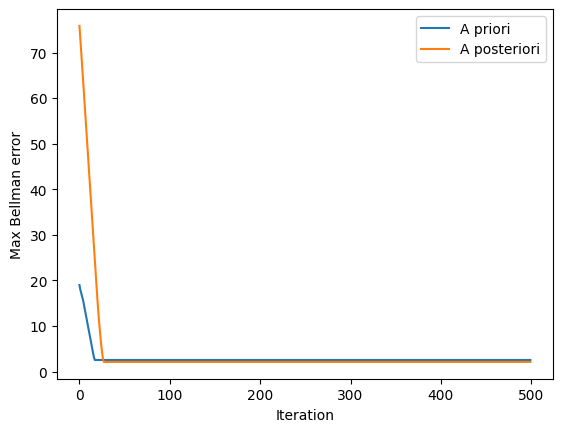

In [86]:
plt.plot(conv_apriori, label="A priori")
plt.plot(conv_aposteriori, label="A posteriori")

#plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Max Bellman error")
plt.legend()
plt.show()

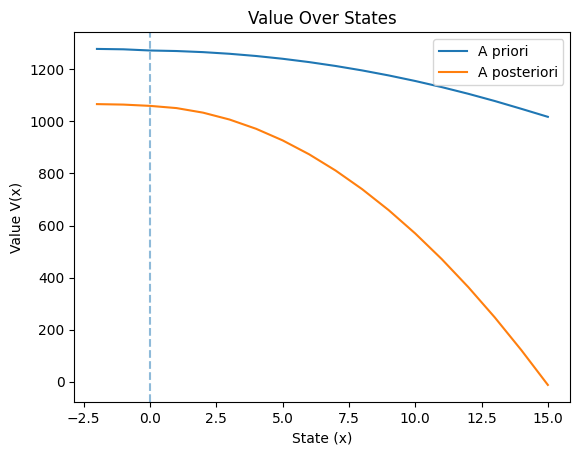

In [87]:
# It is interesting that most of the time, it is better to just do a priori, which means you 
plt.plot(states, V_apriori, label="A priori")
plt.plot(states, V_aposteriori, label="A posteriori")

plt.title("Value Over States")
plt.axvline(0, linestyle="--", alpha=0.5)
plt.xlabel("State (x)")
plt.ylabel("Value V(x)")
plt.legend()
plt.show()

# We now do a sensitivity analysis over the class rewards

In [88]:
def extract_threshold(V, params):
    """extract the threshold given the value function and params"""
    states = build_state_space(params)

    for i, x in enumerate(states):

        if x < 0:
            continue

        vq = V[min(i + 1, len(states) - 1)]

        outsource_value = V[i] - params.outsourcing_cost

        if outsource_value > vq:
            return x

    return None

In [89]:
def to_dataframe(results, r1_vals, r2_vals):
    """given the results from the sensitivity analysis,
    create a dataframe/table"""

    df = pd.DataFrame(index=r2_vals, columns=r1_vals)

    for r2 in r2_vals:
        for r1 in r1_vals:

            t = results[r2][r1]

            if t is None:
                df.loc[r2, r1] = "always accept"
            elif t == 0:
                df.loc[r2, r1] = "immediate outsource"
            else:
                df.loc[r2, r1] = f"x < {t} accept"

    df.index.name = "r2 \\ r1"
    return df


In [90]:
results_apriori = {}
results_aposteriori = {}

class1_rewards = list(range(1, 11))
class2_rewards = [10, 8, 6, 4, 2, 1]


for r2 in class2_rewards:

    results_apriori[r2] = {}
    results_aposteriori[r2] = {}

    for r1 in class1_rewards:

        # IMPORTANT: do NOT mutate original params
        local_params = QueueingSystemParams(
            arrival_rate=params.arrival_rate,
            num_servers=params.num_servers,
            service_rate=params.service_rate,
            class2_arrival_rate=params.class2_arrival_rate,

            class1_reward=r1,
            class2_reward=r2,
            outsourcing_cost=params.outsourcing_cost,
            congestion_sensitivity=params.congestion_sensitivity,

            max_queue_length=params.max_queue_length,
            convergence_tolerance=params.convergence_tolerance,
            max_iterations=params.max_iterations
        )

        # solve
        V_a, _ = solve(bellman_update_apriori, local_params)
        V_b, _ = solve(bellman_update_aposteriori, local_params)

        # extract threshold (THIS was missing)
        ta = extract_threshold(V_a, local_params)
        tb = extract_threshold(V_b, local_params)

        results_apriori[r2][r1] = ta
        results_aposteriori[r2][r1] = tb

In [91]:
df_apriori = to_dataframe(results_apriori, class1_rewards, class2_rewards)
df_aposteriori = to_dataframe(results_aposteriori, class1_rewards, class2_rewards)

In [92]:
df_apriori[::-1]

,1,2,3,4,5,6,7,8,9,10
r2 \ r1,,,,,,,,,,
1,x < 4 accept,x < 2 accept,x < 2 accept,x < 2 accept,x < 1 accept,x < 1 accept,x < 1 accept,x < 1 accept,x < 1 accept,x < 1 accept
2,x < 3 accept,x < 2 accept,x < 1 accept,x < 1 accept,x < 1 accept,x < 1 accept,x < 1 accept,x < 1 accept,x < 1 accept,x < 1 accept
4,immediate outsource,x < 1 accept,x < 1 accept,x < 1 accept,x < 1 accept,x < 1 accept,x < 1 accept,x < 1 accept,x < 1 accept,x < 1 accept
6,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,x < 1 accept,x < 1 accept
8,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource
10,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource


In [94]:
df_aposteriori[::-1]

,1,2,3,4,5,6,7,8,9,10
r2 \ r1,,,,,,,,,,
1,x < 1 accept,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource
2,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource
4,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource
6,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource
8,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource
10,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource,immediate outsource


No matter what, it seems so interesting that outsourcing is always just better. Like, damn....